In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/jena_climate_2009_2016.csv')

In [38]:
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [39]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [40]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  object 
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/mol)  420551 non-null  float64
 11  rho (g/m**3)     420551 non-null  float64
 12  wv (m/s)         420551 non-null  float64
 13  max. wv (m/s)    420551 non-null  float64
 14  wd (deg)         420551 non-null  float64
dtypes: float64(14), object(1)
memory usage: 48.1+ MB


**discovering nulls and filling it**

In [41]:
df.isna().sum()

,0
Date Time,0
p (mbar),0
T (degC),0
Tpot (K),0
Tdew (degC),0
rh (%),0
VPmax (mbar),0
VPact (mbar),0
VPdef (mbar),0
sh (g/kg),0


In [42]:
df = df.interpolate()
#as our data has nulls between small gaps so that we can filling with interpolation safely

/tmp/ipython-input-4248604237.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate()


In [43]:
df.isnull().sum()

,0
Date Time,0
p (mbar),0
T (degC),0
Tpot (K),0
Tdew (degC),0
rh (%),0
VPmax (mbar),0
VPact (mbar),0
VPdef (mbar),0
sh (g/kg),0


# **feature engineering (circular encoding)**

In [44]:
#adapting data types to be in date time format
df['Date Time'] = pd.to_datetime(df['Date Time'] , format='mixed')
df = df.set_index('Date Time')


In [45]:
# This part is for showing the hours that doesn't exist in the original dataset
# Where pandas create rows for these hours even they don't exist in the orignal dataset
counts = df.resample("1H").count()
counts[counts == 0].dropna(how="all")


/tmp/ipython-input-772640908.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  counts = df.resample("1H").count()


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2014-09-24 18:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-09-24 19:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-09-24 20:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-09-24 21:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-09-24 22:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-10-28 07:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-10-28 08:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-10-28 09:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [46]:

#1- resampling data to be hourly instead of 10 min interval
df_hourly = df.resample('1H').mean().reset_index()

/tmp/ipython-input-3356482445.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('1H').mean().reset_index()


In [47]:
#2- adding col hour , month but using the sin and cos as i want the cyclicity means in month (1 - 12 )are adjecents
# extracting raw hour and month integers
df_hourly['hour'] = df_hourly['Date Time'].dt.hour

#For Hour (Max Value = 24)
hours_in_day = 24
df_hourly['hour_sin'] = np.sin(df_hourly['hour'] * (2. * np.pi / hours_in_day))
df_hourly['hour_cos'] = np.cos(df_hourly['hour'] * (2. * np.pi / hours_in_day))

#MODIFICATION_2
#Seasonal cycle (day of year - more precise than month)
df_hourly['day_of_year'] = df_hourly['Date Time'].dt.dayofyear
df_hourly['doy_sin'] = np.sin(2*np.pi*df_hourly['day_of_year']/365.25)
df_hourly['doy_cos'] = np.cos(2*np.pi*df_hourly['day_of_year']/365.25)


In [48]:
df_hourly.isnull().sum()

,0
Date Time,0
p (mbar),88
T (degC),88
Tpot (K),88
Tdew (degC),88
rh (%),88
VPmax (mbar),88
VPact (mbar),88
VPdef (mbar),88
sh (g/kg),88


In [49]:
df_hourly = df_hourly.interpolate()


In [50]:
df_hourly.isnull().sum().sum()

np.int64(0)

In [51]:
df.head(10)

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
2009-01-01 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
2009-01-01 01:10:00,996.50,-7.62,265.81,-8.30,94.8,3.44,3.26,0.18,2.04,3.27,1305.68,0.18,0.63,166.5
2009-01-01 01:20:00,996.50,-7.62,265.81,-8.36,94.4,3.44,3.25,0.19,2.03,3.26,1305.69,0.19,0.50,118.6
2009-01-01 01:30:00,996.50,-7.91,265.52,-8.73,93.8,3.36,3.15,0.21,1.97,3.16,1307.17,0.28,0.75,188.5


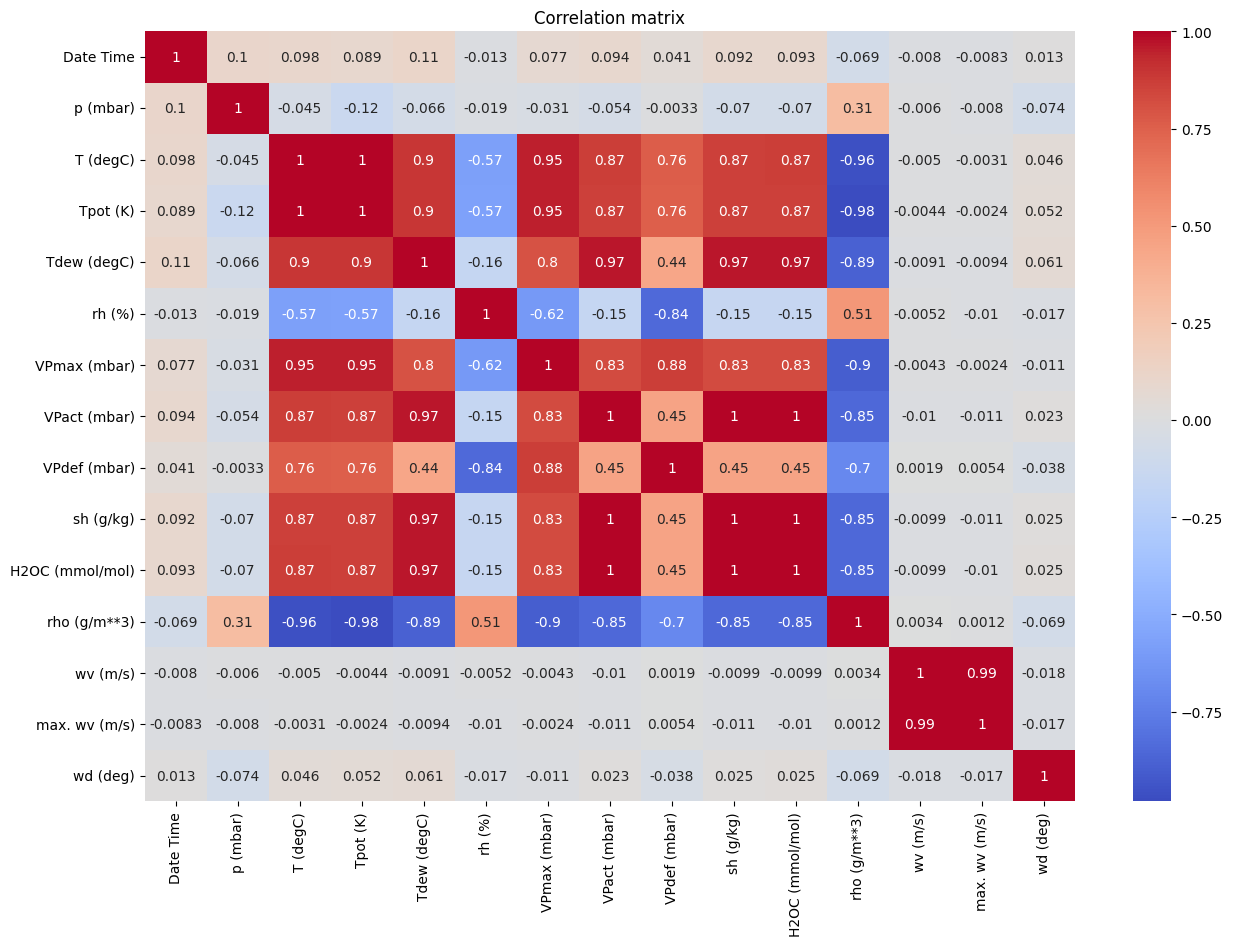

In [52]:
#heatmap to see the correlations
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize= (15 , 10))
corr_mat= df_hourly.drop(columns=['hour_sin' , 'hour_cos' , 'doy_sin' , 'doy_cos' , 'hour' ,'day_of_year']).corr()
sns.heatmap(corr_mat , cmap='coolwarm' , annot = True)
plt.title('Correlation matrix')
plt.show()

## **droping unnessecary columns (really week correlation)**

In [53]:
#Modification_3
#dropping the unnessecay cols that don't affect on out target like wd , wv also the highly correlated features like the same temp but with kilven
abs(corr_mat['T (degC)']).sort_values()
features_to_keep = [
        'T (degC)', 'p (mbar)', 'Tdew (degC)', 'rh (%)',
        'VPmax (mbar)', 'VPact (mbar)', 'sh (g/kg)',
        'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)',
        'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos'
    ]
df = df_hourly[features_to_keep]

## **splitting before normalization**

In [54]:
#after preprocessing all the data (feature eng , drop unessecary cols ) except the normalizationnnn

#TEMPORAL SPLIT first
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_raw = df.iloc[:train_size].copy()
val_raw = df.iloc[train_size:train_size+val_size].copy()
test_raw = df.iloc[train_size+val_size:].copy()

print(f"Train: {train_raw.index[0]} to {train_raw.index[-1]}")
print(f"Val:   {val_raw.index[0]} to {val_raw.index[-1]}")
print(f"Test:  {test_raw.index[0]} to {test_raw.index[-1]}")


Train: 0 to 49089
Val:   49090 to 59608
Test:  59609 to 70128


## **Normalization using standard scaler but on each col separetly(better results)**

In [55]:
# normalization
#normalizing each col separately and saving the scalers as i want to inverse the scalers while after the prediction

from sklearn.preprocessing import StandardScaler

# Initialize scalers (one per column)
scaler_dict = {}

# 5. Fit scalers ONLY on training data
for column in train_raw.columns:
    scaler = StandardScaler()
    scaler.fit(train_raw[[column]])  # ONLY TRAINING DATA!
    scaler_dict[column] = scaler

# 6. Transform all sets using TRAINING statistics
def scale_data(data_df, scaler_dict):
    scaled_df = pd.DataFrame(index=data_df.index)
    for column in data_df.columns:
        scaler = scaler_dict[column]
        scaled_df[column] = scaler.transform(data_df[[column]]).flatten()
    return scaled_df

train_scaled = scale_data(train_raw, scaler_dict)
val_scaled = scale_data(val_raw, scaler_dict)
test_scaled = scale_data(test_raw, scaler_dict)


#saving the scalers for using it in streamlit app latter
#already saved i will not run this again instead i will comment it
# import pickle
# import json
# import os

# # saving scalers for streamlit app
# # creating directory for artifacts (if it doesn't exist)
# artifacts_dir = 'preprocessing_artifacts'
# os.makedirs(artifacts_dir, exist_ok=True)

# # saving the COMPLETE scaler dictionary
# with open(f'{artifacts_dir}/scaler_dict.pkl', 'wb') as f:
#     pickle.dump(scaler_dict, f)

# print(f"✅ Saved {len(scaler_dict)} scalers to '{artifacts_dir}/scaler_dict.pkl'")



### ***Verifying applying normalization approperiatly***

In [56]:
print("\n=== VERIFICATION ===")
print("Training data after scaling (should have ~mean=0, ~std=1):")
for col in ['T (degC)' , 'rh (%)']:
    print(f"  {col}: mean={train_scaled[col].mean():.6f}, std={train_scaled[col].std():.6f}")

print("\nTest data after scaling (using TRAINING statistics):")
for col in ['T (degC)','rh (%)']:
    print(f"  {col}: mean={test_scaled[col].mean():.6f}, std={test_scaled[col].std():.6f}")
    print(f"    (Note: Not exactly 0 and 1, which is CORRECT!)")


=== VERIFICATION ===
Training data after scaling (should have ~mean=0, ~std=1):
  T (degC): mean=0.000000, std=1.000010
  rh (%): mean=-0.000000, std=1.000010

Test data after scaling (using TRAINING statistics):
  T (degC): mean=0.072175, std=0.915772
    (Note: Not exactly 0 and 1, which is CORRECT!)
  rh (%): mean=0.017640, std=0.951310
    (Note: Not exactly 0 and 1, which is CORRECT!)


## ***Data Generation***

> (for predicting the temp for the next 12 h using the past 720 h (5 days)



In [57]:
from tensorflow import keras
# Parameters
sequence_length = 72   #look for the previous 72 hours
sampling_rate = 1
batch_size = 128 # if i used 256 may cause potential overfitting , less genralization
delay = 12       #predicting the next 12 ones
target_col = 'T (degC)'  # Your target column


# ***converting into numy array to be appropriate for tensorflow***

In [58]:
train_array = train_scaled.values
val_array = val_scaled.values
test_array = test_scaled.values

# Find temperature column index
target_idx = train_scaled.columns.get_loc(target_col)
print(f"Target column '{target_col}' is at index {target_idx}")

Target column 'T (degC)' is at index 0


## ***function for generation***

In [59]:
# Function to create correctly aligned datasets
def create_multivariate_dataset(data_array, target_idx, sequence_length,
                                sampling_rate, delay, batch_size, shuffle=False):
    """
    Creates multivariate time series dataset with correct alignment

    Args:
        data_array: (n_timesteps, n_features) - ALL features
        target_idx: Index of temperature column
        sequence_length: Lookback window
        sampling_rate: How often to sample
        delay: How many steps ahead to predict
        batch_size: Batch size
        shuffle: Whether to shuffle (only for training)
    """
    # Calculate total offset
    total_offset = sequence_length + delay

    # Create targets: temperature at total_offset steps ahead
    # We need to align targets with the end of each input sequence
    targets = data_array[total_offset:, target_idx]  # Only temperature!

    # Input data: everything except the last 'delay' steps
    # (because we can't predict beyond available data)
    input_data = data_array[:-delay] if delay > 0 else data_array

    # Create dataset
    dataset = keras.utils.timeseries_dataset_from_array(
        data=input_data,
        targets=targets,
        sequence_length=sequence_length,
        sampling_rate=sampling_rate,
        sequence_stride=1,
        batch_size=batch_size,
        shuffle=shuffle,
        seed=42 if shuffle else None
    )

    return dataset

## **generation step**

In [60]:

# Create datasets
print(f"\nCreating datasets with:")
print(f"  Sequence length: {sequence_length} steps ({sequence_length/24:.1f} days)")
print(f"  Sampling rate: {sampling_rate} (hourly samples)")
print(f"  Delay: {delay} steps ({delay/sampling_rate:.1f} hours ahead)")
print(f"  Batch size: {batch_size}")

train_dataset = create_multivariate_dataset(
    data_array=train_array,
    target_idx=target_idx,
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    delay=delay,
    batch_size=batch_size,
    shuffle=True  # Only for training
)

val_dataset = create_multivariate_dataset(
    data_array=val_array,
    target_idx=target_idx,
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    delay=delay,
    batch_size=batch_size,
    shuffle=False  # Never shuffle validation/test
)

test_dataset = create_multivariate_dataset(
    data_array=test_array,
    target_idx=target_idx,
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    delay=delay,
    batch_size=batch_size,
    shuffle=False
)


Creating datasets with:
  Sequence length: 72 steps (3.0 days)
  Sampling rate: 1 (hourly samples)
  Delay: 12 steps (12.0 hours ahead)
  Batch size: 128


In [61]:
# 3. VERIFICATION

print("\nStep 3: Verifying datasets...")

# Check one batch from each dataset
print("\nTraining dataset:")
for batch_x, batch_y in train_dataset.take(1):
    print(f"  Batch X shape: {batch_x.shape}")  # Should be (batch, seq_len, features)
    print(f"  Batch y shape: {batch_y.shape}")  # Should be (batch,)
    print(f"  Number of features: {batch_x.shape[2]}")
    print(f"  First target (scaled temp): {batch_y[0].numpy():.3f}")

print("\nValidation dataset:")
for batch_x, batch_y in val_dataset.take(1):
    print(f"  Batch X shape: {batch_x.shape}")
    print(f"  Batch y shape: {batch_y.shape}")


Step 3: Verifying datasets...

Training dataset:
  Batch X shape: (128, 72, 14)
  Batch y shape: (128,)
  Number of features: 14
  First target (scaled temp): 1.001

Validation dataset:
  Batch X shape: (128, 72, 14)
  Batch y shape: (128,)


In [62]:
# normalization standard scaler -> done
# outlier threshold , visulaization , nulls -> inspect , clean -> done
# splitting data (720 past , 24 future) -> done
# date generation -> done

# ***LSTM Implementation***

A contiguous subset of the dataset was sampled while keeping the same input features and target column. This allows for fast heuristic exploration of different LSTM architectures and hyperparameters before scaling the best configuration to the full dataset.

In [63]:
sample_size = 5000  # number of timesteps you want to experiment with
sample_train = train_scaled.iloc[:sample_size].copy()
sample_val = val_scaled.iloc[:int(sample_size*0.2)].copy()  # small val sample
sample_test = test_scaled.iloc[:int(sample_size*0.2)].copy() # small test sample


In [64]:
train_array_sample = sample_train.values
val_array_sample = sample_val.values
test_array_sample = sample_test.values

# Use your create_multivariate_dataset function
sequence_length =240
delay = 12
batch_size = 128
target_idx = sample_train.columns.get_loc('T (degC)')  # temperature column

train_dataset_sample = create_multivariate_dataset(
    train_array_sample, target_idx, sequence_length, 1, delay, batch_size, shuffle=True
)
val_dataset_sample = create_multivariate_dataset(
    val_array_sample, target_idx, sequence_length, 1, delay, batch_size, shuffle=False
)
test_dataset_sample = create_multivariate_dataset(
    test_array_sample, target_idx, sequence_length, 1, delay, batch_size, shuffle=False
)


In [65]:
# Performance optimization
train_dataset_sample = train_dataset_sample.cache().prefetch(tf.data.AUTOTUNE)
val_dataset_sample   = val_dataset_sample.cache().prefetch(tf.data.AUTOTUNE)

# =====================================================
# 2. MODEL BUILDER (SEARCH-FRIENDLY)
# =====================================================
def build_lstm_model(input_shape, units, num_layers, dropout):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    for i in range(num_layers):
        x = layers.LSTM(
            units,
            return_sequences=(i < num_layers - 1),
            kernel_regularizer=keras.regularizers.l2(1e-4)
        )(x)
        x = layers.Dropout(dropout)(x)

    x = layers.Dense(16, activation="relu")(x)
    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model

# =====================================================
# 3. INPUT SHAPE
# =====================================================
for x_batch, _ in train_dataset_sample.take(1):
    input_shape = x_batch.shape[1:]
    break

# =====================================================
# 4. SCALE steps_per_epoch CORRECTLY
# =====================================================
FULL_STEPS = 50                      # known good on FULL dataset
full_train_size = len(train_scaled)  # full data size
sample_size = len(sample_train)      # your sample size

steps_per_epoch_sample = max(
    1,
    int(FULL_STEPS * (sample_size / full_train_size))
)

print("Search steps_per_epoch:", steps_per_epoch_sample)

# =====================================================
# 5. SEARCH SPACE (SMALL & LOGICAL)
# =====================================================
layer_options   = [1, 2]
unit_options    = [32, 64]
dropout_options = [0.2, 0.3]

results = []

# =====================================================
# 6. HYPERPARAMETER SEARCH
# =====================================================
for num_layers in layer_options:
    for units in unit_options:
        for dropout in dropout_options:

            print(f"\nSearching → layers={num_layers}, units={units}, dropout={dropout}")

            model = build_lstm_model(
                input_shape=input_shape,
                units=units,
                num_layers=num_layers,
                dropout=dropout
            )

            history = model.fit(
                train_dataset_sample,
                validation_data=val_dataset_sample,
                epochs=20,
                steps_per_epoch=steps_per_epoch_sample,
                verbose=0,
                callbacks=[
                    keras.callbacks.EarlyStopping(
                        monitor="val_loss",
                        patience=4,
                        restore_best_weights=True
                    )
                ]
            )

            val_loss, val_mae = model.evaluate(
                val_dataset_sample, verbose=0
            )

            results.append({
                "layers": num_layers,
                "units": units,
                "dropout": dropout,
                "val_mae": val_mae,
                "val_mse": val_loss
            })

            print(f"→ Val MAE: {val_mae:.4f}")

# =====================================================
# 7. SHOW BEST CONFIGS
# =====================================================
results = sorted(results, key=lambda x: x["val_mae"])

print("\nTOP RESULTS:")
for r in results[:3]:
    print(r)


Search steps_per_epoch: 5

Searching → layers=1, units=32, dropout=0.2


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


→ Val MAE: 0.3814

Searching → layers=1, units=32, dropout=0.3
→ Val MAE: 0.3839

Searching → layers=1, units=64, dropout=0.2
→ Val MAE: 0.3803

Searching → layers=1, units=64, dropout=0.3
→ Val MAE: 0.3793

Searching → layers=2, units=32, dropout=0.2
→ Val MAE: 0.3917

Searching → layers=2, units=32, dropout=0.3
→ Val MAE: 0.4058

Searching → layers=2, units=64, dropout=0.2
→ Val MAE: 0.3921

Searching → layers=2, units=64, dropout=0.3
→ Val MAE: 0.4221

TOP RESULTS:
{'layers': 1, 'units': 64, 'dropout': 0.3, 'val_mae': 0.3793479800224304, 'val_mse': 0.298125296831131}
{'layers': 1, 'units': 64, 'dropout': 0.2, 'val_mae': 0.3802988827228546, 'val_mse': 0.26776474714279175}
{'layers': 1, 'units': 32, 'dropout': 0.2, 'val_mae': 0.38141724467277527, 'val_mse': 0.2883478105068207}


In [70]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# =========================
# 1. Full dataset arrays
# =========================
train_array_full = train_scaled.values
val_array_full = val_scaled.values
test_array_full = test_scaled.values

sequence_length = 240
delay = 12
batch_size = 128
target_idx = train_scaled.columns.get_loc('T (degC)')

train_dataset_full = create_multivariate_dataset(
    train_array_full, target_idx,
    sequence_length, 1, delay,
    batch_size, shuffle=True
)

val_dataset_full = create_multivariate_dataset(
    val_array_full, target_idx,
    sequence_length, 1, delay,
    batch_size, shuffle=False
)

test_dataset_full = create_multivariate_dataset(
    test_array_full, target_idx,
    sequence_length, 1, delay,
    batch_size, shuffle=False
)

# =========================
# 2. Build FULL LSTM model (from search)
# =========================
def build_lstm_full(input_shape):
    inputs = keras.Input(shape=input_shape)

    x = layers.LSTM(64)(inputs)      # ✅ units = 64
    x = layers.Dropout(0.3)(x)       # ✅ dropout = 0.3
    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",                  # ✅ same metric used in search
        metrics=["mae"]
    )

    return model

# =========================
# 3. Get input shape
# =========================
for x_batch, y_batch in train_dataset_full.take(1):
    input_shape = x_batch.shape[1:]
    break

# =========================
# 4. Train on FULL dataset
# =========================
lstm_model_full = build_lstm_full(input_shape)

history = lstm_model_full.fit(
    train_dataset_full,
    validation_data=val_dataset_full,
    steps_per_epoch=50,
    epochs=20,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ]
)

# =========================
# 5. Evaluate
# =========================
test_loss, test_mae = lstm_model_full.evaluate(test_dataset_full)
print(f"Test MAE: {test_mae:.4f}, Test MSE: {test_loss:.4f}")


Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 49s 832ms/step - loss: 0.5283 - mae: 0.5475 - val_loss: 0.2475 - val_mae: 0.3693
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 577ms/step - loss: 0.3339 - mae: 0.4236 - val_loss: 0.2428 - val_mae: 0.3622
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 588ms/step - loss: 0.3025 - mae: 0.4011 - val_loss: 0.2366 - val_mae: 0.3588
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 598ms/step - loss: 0.2957 - mae: 0.3918 - val_loss: 0.2418 - val_mae: 0.3626
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 579ms/step - loss: 0.3020 - mae: 0.3891 - val_loss: 0.2457 - val_mae: 0.3671
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 595ms/step - loss: 0.2616 - mae: 0.3743 - val_loss: 0.2383 - val_mae: 0.3596
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 590ms/step - loss: 0.2605 - mae: 0.3725 - val_loss: 0.2380 - val_mae: 0.3597
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 430ms/step - loss: 0.2715 - mae: 0.3724 - val_loss: 0.2367 - val_mae: 0.3578
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 163ms/step - loss

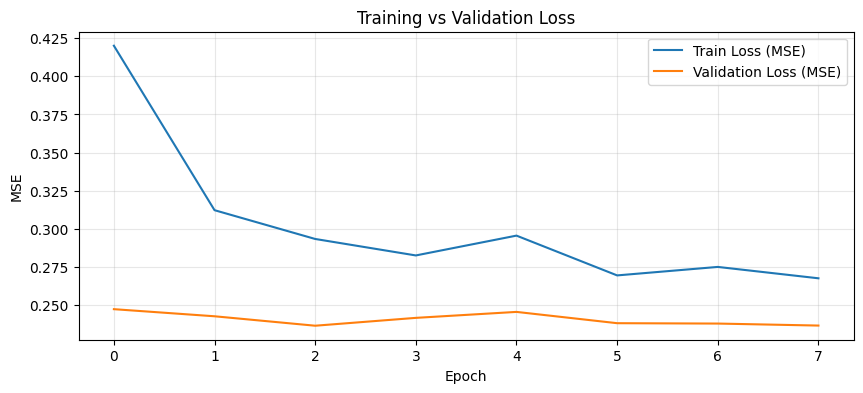

In [74]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# =========================
# Plot first 200 predictions vs true
# =========================
y_true = None
y_pred = None

for x_batch, y_batch in test_dataset_full.take(3):
    y_true = y_batch.numpy().flatten()
    y_pred = lstm_model_full.predict(x_batch).flatten()
    break

plt.figure(figsize=(12,4))
plt.plot(y_true[:300], label="True", linewidth=2)
plt.plot(y_pred[:300], label="Predicted", linewidth=2)
plt.title("Predicted vs True Temperature (first 300 samples)")
plt.xlabel("Time step")
plt.ylabel("Temperature (scaled)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [73]:
lstm_model_full.save("lstm_full_model.keras")

# To load it later
from tensorflow.keras.models import load_model
loaded_model = load_model("lstm_full_model.keras")


In [ ]:
# Take the first batch from the test dataset
for x_batch, y_batch in test_dataset_full.take(1):
    y_true = y_batch.numpy().flatten()
    y_pred = lstm_model_full.predict(x_batch).flatten()
    break

# Select 20 random indices
num_samples = 10
indices = np.random.choice(len(y_true), size=num_samples, replace=False)

# Print random predictions vs true values
print("Random Prediction\t|\tTrue Value")
print("-"*35)
for idx in indices:
    print(f"{y_pred[idx]:.4f}\t|\t{y_true[idx]:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Random Prediction	|	True Value
-----------------------------------
-0.5341	|	-0.6953
-0.9707	|	-0.9610
-0.2084	|	-0.3220
-0.4304	|	-0.7478
-0.8307	|	-0.5010
-0.0705	|	0.4244
-0.3108	|	1.1311
-0.7351	|	-0.6359
-0.0481	|	-0.7397
0.3745	|	0.4092
